In [38]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import trange
import sys
import importlib

In [39]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

using gpu:0 device 



2026-09-02 21:15:44.607624: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-02 21:15:44.607688: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [40]:
import affine

In [41]:
sys.path.append("../src/")
import PCA_emulator
importlib.reload(PCA_emulator)
import os
ipynb_path = os.path.dirname(os.path.realpath("__file__"))

# load your trained emulators

In [42]:
tt_emu_model = PCA_emulator.PCAplusNN(restore=True,
                                restore_filename='../data/TT_cp_PCAplusNN_example_large' )

te_emu_model = PCA_emulator.PCAplusNN(restore=True,
                                restore_filename='../data/TE_cp_PCAplusNN_example_large'
                               )

ee_emu_model = PCA_emulator.PCAplusNN(restore=True,
                                restore_filename='../data/EE_cp_PCAplusNN_example_large'
                               )

In [43]:
tt_emu_model.parameters

ListWrapper(['h', 'tau_reio', 'omega_b', 'n_s', 'ln10^{10}A_s', 'omega_cdm'])

# load the likelihood code

In [44]:

sys.path.append(
    '/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS/src/likelihoods/tf_planck2018_lite/'
)

import tf_planck2018_lite
importlib.reload(tf_planck2018_lite)

from tf_planck2018_lite import tf_planck2018_lite

# pass the parameters to likelihood code in same order you arrange them in emulator
To check the order of your parameters in emulator run 'tt_emu_model.parameters' and it has to be same for TT, TE and EE emulators

In [74]:

import tensorflow as tf 
import tensorflow_probability as tfp
# path to the tf_planck2018_lite likelihood
tf_planck2018_lite_path = '/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS/src/likelihoods/tf_planck2018_lite/'
np.random.seed(12345)
tf.random.set_seed(12345)
# parameters of the analysis, and their priors
parameters_and_priors = {'h':            [0.2,   1.0,   'uniform'],
                         'tau_reio':     [0.02,  0.1,   'uniform'],
                         'omega_b':      [0.001, 0.04, 'uniform'],
                         'n_s':          [0.9,   1.1,   'uniform'],
                         'ln10^{10}A_s': [1.61,  3.91,  'uniform'],
                         'omega_cdm':    [0.005, 0.99,  'uniform'],                  
                         
                         'A_planck':     [1.0,   0.01,  'gaussian'],
                          }

# instantiation
tf_planck = tf_planck2018_lite(parameters=parameters_and_priors, 
                                  tf_planck2018_lite_path=tf_planck2018_lite_path,
                                  tt_emu_model=tt_emu_model,
                                  te_emu_model=te_emu_model,
                                  ee_emu_model=ee_emu_model
                                  )

FIDUCIAL = np.reshape(np.array([ 0.673,0.055,  0.022242, 0.9658,3.0753,0.11977, 1.0080]).astype('float32'), (1, 7))
EPSILON  = np.reshape(np.array([ 1E-2,    1E-3,  1E-4,    1E-3,    1E-3, 1E-4,1E-4]).astype('float32'), (1,7))



In [15]:
# define the log-likelihood, like you do to run 'emcee' sampling code (MCMC package)

In [75]:
@tf.function
def log_prob(theta):
    return tf.squeeze(tf_planck.posterior(theta), -1)

In [69]:
# number of parameters
n_params = len(parameters_and_priors)

# number of walkers (note you'll end up with a total of 2*n_walkers for this parallel variant of the affine sampler)
n_walkers = 500

# initialize walkers and current state
walkers1 = tf.random.normal([n_walkers, n_params], FIDUCIAL, EPSILON)
walkers2 = tf.random.normal([n_walkers, n_params], FIDUCIAL, EPSILON)
current_state = [walkers1, walkers2]

In [70]:
# number of MCMC steps (chain shape: [n_steps, 2*n_walkers, n_parameters])
n_steps = 3000

# run the sampler
with tf.device(device):
    chain = affine.affine_sample(log_prob, n_steps, current_state, args=[])

Tensor("transpose_1:0", shape=(500, 6), dtype=float32)


2026-09-02 21:37:03.886161: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
100%|██████████████████████████████████████████████████████████████████████████████████| 2999/2999 [03:46<00:00, 13.23it/s]


In [76]:
# plot the results...

# how many burnin steps to remove
burnin_steps = 200
samples = chain.numpy()[burnin_steps:,:,:].reshape((-1, n_params))
samples=samples[:,:6] # keep the 6-Lambda CDM parameters only

In [35]:
#np.save("check_same_samples.npy",samples)

In [37]:
!pwd

/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS/notebook


In [ ]:
#samples = np.load('/Users/debabrata/Documents/conferences/India/codes/my_codes/notebook/check_same_samples.npy')

In [77]:
samples.shape

(2800000, 6)

In [32]:
!pip install getdist

In [78]:
from getdist import plots, MCSamples


names = [r"h",  r"\tau",r"\omega_{\mathrm{b}}",r"n_s", r"ln 10^{10} A_s", r"\omega_{\mathrm{cdm}}",]
        
         #r"A_{\mathrm{Planck}}"]
labels = names
mcsamples = MCSamples(samples=samples,names = names, labels = labels)
g = plots.get_subplot_plotter()
g.settings.axes_fontsize = 18
g.settings.lab_fontsize = 30
g.settings.legend_fontsize = 50

Removed no burn in


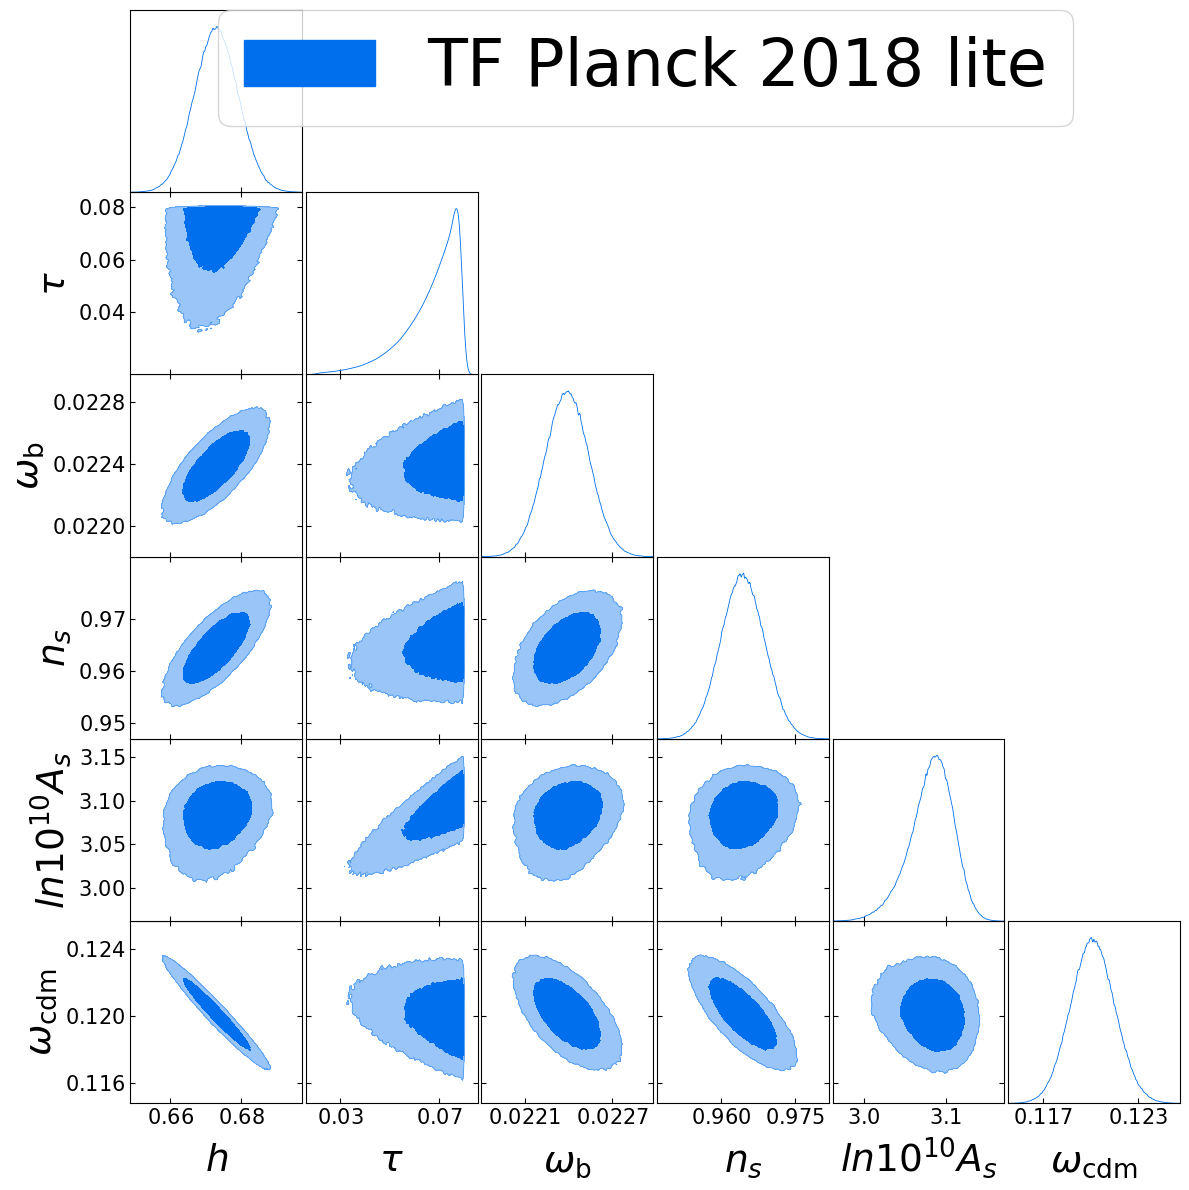

In [79]:
g.triangle_plot([mcsamples], filled=True, legend_labels=['TF Planck 2018 lite'])

In [61]:
from getdist import loadMCSamples
samples_p = loadMCSamples(
    '/Users/debabrata/Documents/WORKS/WORKS/Cosmic_Birefringence/planck_likelihoods/COM_CosmoParams_base-plikHM-TTTEEE-lowl-lowE_R3.00/base/plikHM_TTTEEE_lowl_lowE_lensing/base_plikHM_TTTEEE_lowl_lowE_lensing'
)

In [62]:
# Extract Planck chains
omegabh2 = samples_p.getParams().omegabh2
omegach2 = samples_p.getParams().omegach2
H0       = samples_p.getParams().H0
tau      = samples_p.getParams().tau
ns       = samples_p.getParams().ns
logA     = samples_p.getParams().logA


In [63]:
# Reorganise into YOUR emulator order
planck_array = np.column_stack([
    H0 / 100.0,   # h
    tau,          # tau_reio
    omegabh2,     # omega_b
    ns,           # n_s
    logA,         # ln(10^10 A_s)
    omegach2      # omega_cdm
])

minnenames = [
    "h",
    "tau_reio",
    "omega_b",
    "n_s",
    "ln10^{10}A_s",
    "omega_cdm"
]

minnelabels = [
    r"h",
    r"\tau",
    r"\omega_{\mathrm{b}}",
    r"n_s",
    r"\ln(10^{10}A_s)",
    r"\omega_{\mathrm{cdm}}"
]

planck_reorganised = MCSamples(
    samples=planck_array,
    names=minnenames,
    labels=minnelabels,
    label="Planck"
)

Removed no burn in


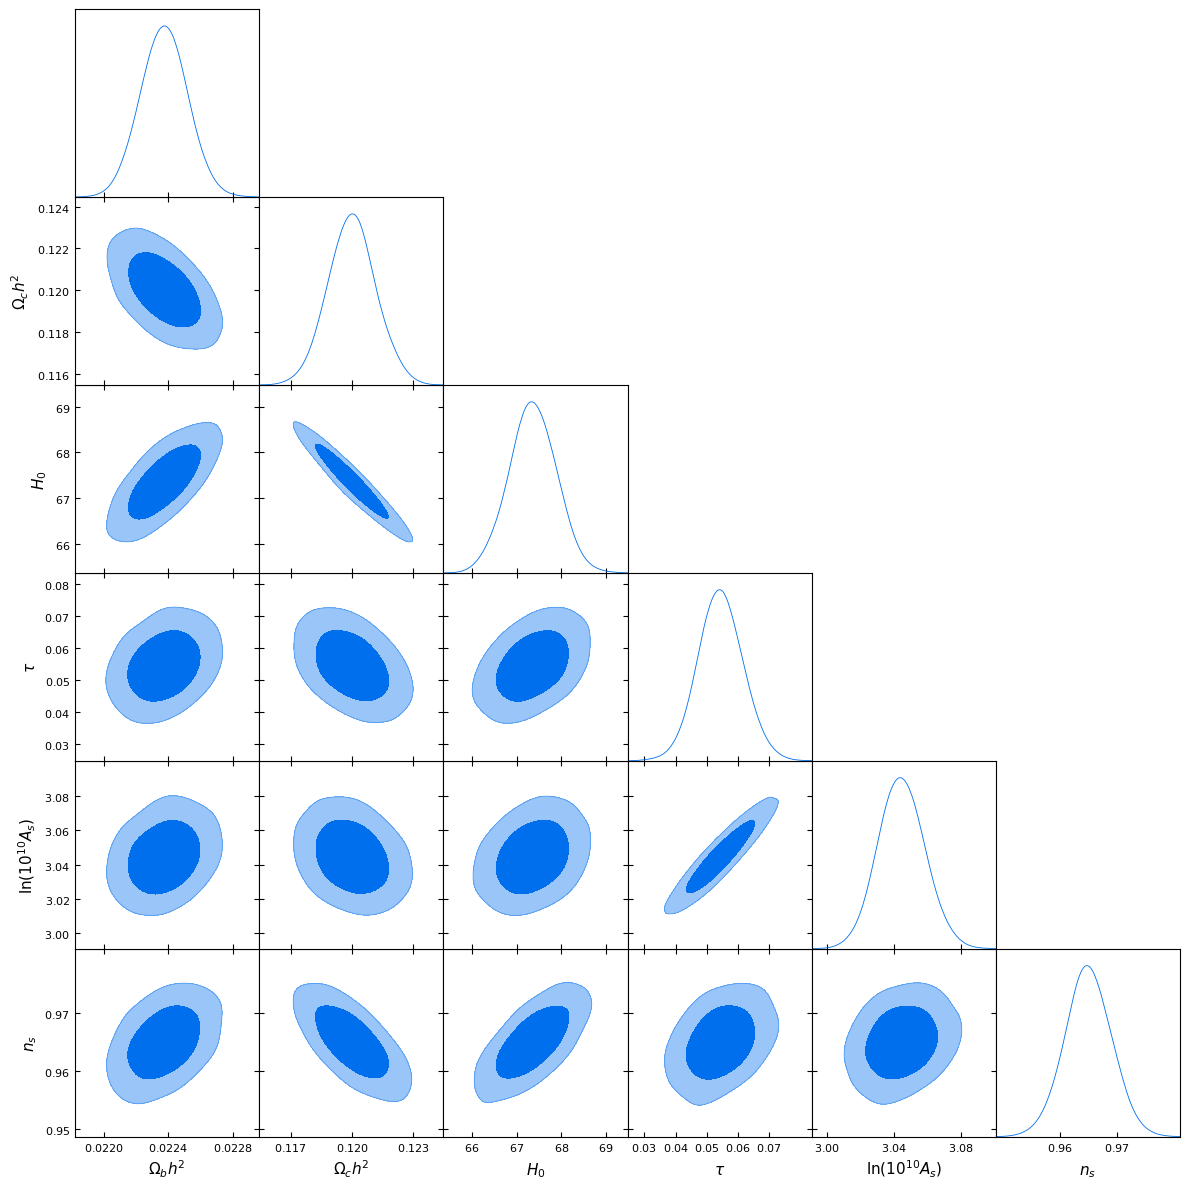

In [64]:
from getdist import plots

g = plots.get_subplot_plotter()

g.triangle_plot(
    samples_p,
    ['omegabh2',
     'omegach2',
     'H0',
     'tau',
     'logA',
     'ns'],
    filled=True
)

In [80]:
my_samples = MCSamples(
    samples=samples,
    names=minnenames,
    labels=minnelabels,
    label="My emulator"
)

Removed no burn in


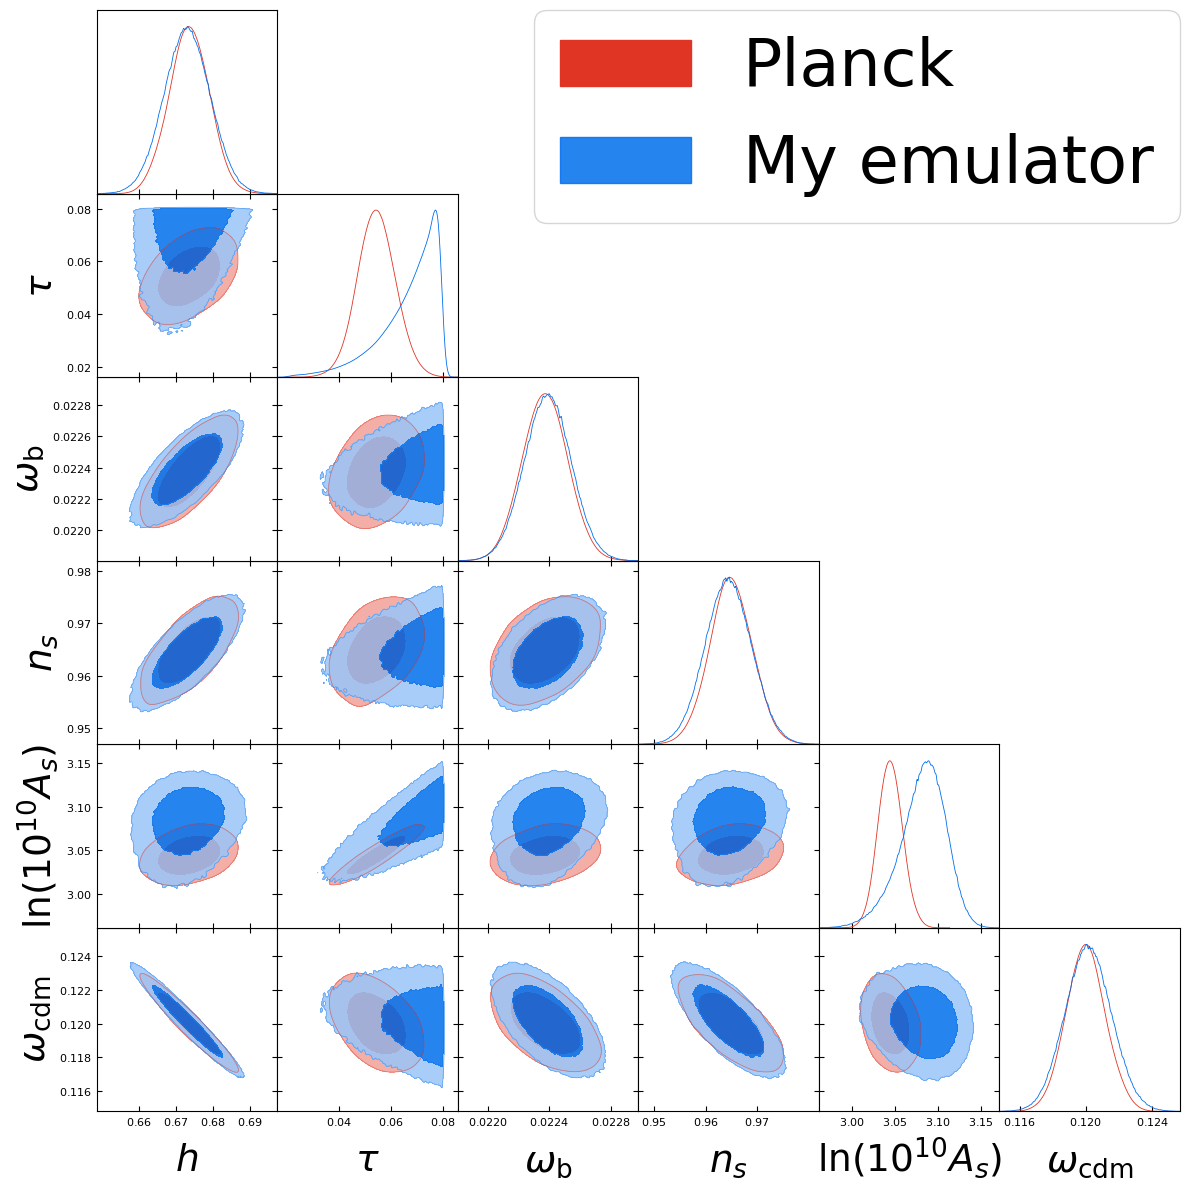

In [81]:
g = plots.get_subplot_plotter()
g.settings.lab_fontsize = 30
g.settings.legend_fontsize = 50
g.triangle_plot(
    [planck_reorganised, my_samples],
    filled=True,
    legend_loc="upper right"
)

In [158]:
params = samples_p.getParams()

# Planck parameters in your emulator order
planck_mean = np.array([
    np.mean(params.H0) / 100.0,
    np.mean(params.tau),
    np.mean(params.omegabh2),
    np.mean(params.ns),
    np.mean(params.logA),
    np.mean(params.omegach2),
])

planck_sigma = np.array([
    np.std(params.H0) / 100.0,
    np.std(params.tau),
    np.std(params.omegabh2),
    np.std(params.ns),
    np.std(params.logA),
    np.std(params.omegach2),
])

names = [
    'h',
    'tau_reio',
    'omega_b',
    'n_s',
    'ln10^{10}A_s',
    'omega_cdm'
]

for name, mean, sigma in zip(names, planck_mean, planck_sigma):
    print(f"{name:15s} = {mean:.8f} +/- {sigma:.8f}")

h               = 0.67357550 +/- 0.00538810
tau_reio        = 0.05437024 +/- 0.00736297
omega_b         = 0.02237212 +/- 0.00014736
n_s             = 0.96489053 +/- 0.00416552
ln10^{10}A_s    = 3.04448135 +/- 0.01423527
omega_cdm       = 0.11999825 +/- 0.00118509


In [182]:
#import cosmopower as cp
import tensorflow as tf 
import tensorflow_probability as tfp
# path to the tf_planck2018_lite likelihood
tf_planck2018_lite_path = '/Users/debabrata/Documents/conferences/India/codes/my_codes/src/likelihoods/tf_planck2018_lite/'

# parameters of the analysis, and their priors
planck_mean = np.asarray(planck_mean, dtype=np.float32)
planck_sigma = 5*np.asarray(planck_sigma, dtype=np.float32)
# BASED ON PLANCK POSTERIORS
"""
parameters_and_priors = {
    'h':            [planck_mean[0], planck_sigma[0], 'gaussian'],
    'tau_reio':     [planck_mean[1], planck_sigma[1], 'gaussian'],
    'omega_b':      [planck_mean[2], planck_sigma[2], 'gaussian'],
    'n_s':          [planck_mean[3], planck_sigma[3], 'gaussian'],
    'ln10^{10}A_s': [planck_mean[4], planck_sigma[4], 'gaussian'],
    'omega_cdm':    [planck_mean[5], planck_sigma[5], 'gaussian'],
    'A_planck':     [np.float32(1.0), np.float32(0.01), 'gaussian'],
}
"""
parameters_and_priors = {
    'h':            [0.2, 1.0, 'uniform'],
    'tau_reio':     [0.01, 0.8, 'uniform'],
    'omega_b':      [0.001, 0.04, 'uniform'],
    'n_s':          [0.9, 1.1, 'uniform'],
    'ln10^{10}A_s': [1.61, 3.91, 'uniform'],
    'omega_cdm':    [0.005, 0.99, 'uniform'],
    'A_planck':     [1.0, 0.01, 'gaussian'],
}
# instantiation
tf_planck = tf_planck2018_lite(parameters=parameters_and_priors, 
                                  tf_planck2018_lite_path=tf_planck2018_lite_path,
                                  tt_emu_model=tt_emu_model,
                                  te_emu_model=te_emu_model,
                                  ee_emu_model=ee_emu_model
                                  )

FIDUCIAL = np.reshape(np.array([ 0.673,0.055,  0.022242, 0.9658,3.0753,0.11977, 1.0080]).astype('float32'), (1, 7))
EPSILON  = np.reshape(np.array([ 1E-2,    1E-3,  1E-4,    1E-3,    1E-3, 1E-4,1E-4]).astype('float32'), (1,7))


In [183]:
@tf.function
def log_prob(theta):
    return tf.squeeze(tf_planck.posterior(theta), -1)

In [184]:
# number of parameters
n_params = len(parameters_and_priors)

# number of walkers (note you'll end up with a total of 2*n_walkers for this parallel variant of the affine sampler)
n_walkers = 500

# initialize walkers and current state
walkers1 = tf.random.normal([n_walkers, n_params], FIDUCIAL, EPSILON)
walkers2 = tf.random.normal([n_walkers, n_params], FIDUCIAL, EPSILON)
current_state = [walkers1, walkers2]

In [185]:
# number of MCMC steps to take (you'll end up with an MCMC chain with shape (n_steps, 2*n_walkers, n_parameters))
n_steps = 3000

# run the sampler
with tf.device(device):
    chain = affine.affine_sample(log_prob, n_steps, current_state, args=[])

Tensor("transpose_1:0", shape=(500, 6), dtype=float32)


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 2999/2999 [01:36<00:00, 31.19it/s]


In [179]:
# plot the results...

# how many burnin steps to remove
burnin_steps = 200
samples = chain.numpy()[burnin_steps:,:,:].reshape((-1, n_params))
samples=samples[:,:6]

# Compare CAMB and NN generated power spectra for some of samples from planck MCMC chains

In [188]:
import numpy as np

params = samples_p.getParams()

# Number of Planck samples to test
N_test = 100

rng = np.random.default_rng(1234)

idx = rng.choice(len(params.H0), size=N_test, replace=False)

planck_params = np.column_stack([
    params.H0[idx] / 100.0,
    params.tau[idx],
    params.omegabh2[idx],
    params.ns[idx],
    params.logA[idx],
    params.omegach2[idx]
])

print(planck_params.shape)

(100, 6)


In [190]:
Cltt_emu = tt_emu_model.ten_to_predictions_tf(
    tf.constant(planck_params, dtype=tf.float32)
).numpy()
Clte_emu = te_emu_model.predictions_tf(
    tf.constant(planck_params, dtype=tf.float32)
).numpy()
Clee_emu = ee_emu_model.ten_to_predictions_tf(
    tf.constant(planck_params, dtype=tf.float32)
).numpy()

In [191]:
Clee_emu.shape

(100, 2507)

In [211]:

ell_range=np.arange(2,Clee_emu.shape[1]+2)#training_features_1['modes']

In [214]:
import camb

Cltt_camb = []
Clte_camb = []
Clee_camb = []

for p in planck_params:

    h, tau, omega_b, ns, logA, omega_cdm = p
    As= np.exp(logA) / 1e10
    pars = camb.set_params(
        H0=100*h,
        ombh2=omega_b,
        omch2=omega_cdm,
        mnu=0.06,
        omk=0,
        tau=tau,
        As=As,
        ns=ns,
        lmax=3000
    )

    

    results = camb.get_results(pars)

    powers = results.get_cmb_power_spectra(
        pars,
        CMB_unit='muK'
    )['total']

    # CAMB columns:
    # TT = 0, EE = 1, BB = 2, TE = 3
    Cltt_camb.append(powers[:, 0])
    Clee_camb.append(powers[:, 1])
    Clte_camb.append(powers[:, 3])

Cltt_camb = np.asarray(Cltt_camb)
Clte_camb = np.asarray(Clte_camb)
Clee_camb = np.asarray(Clee_camb)

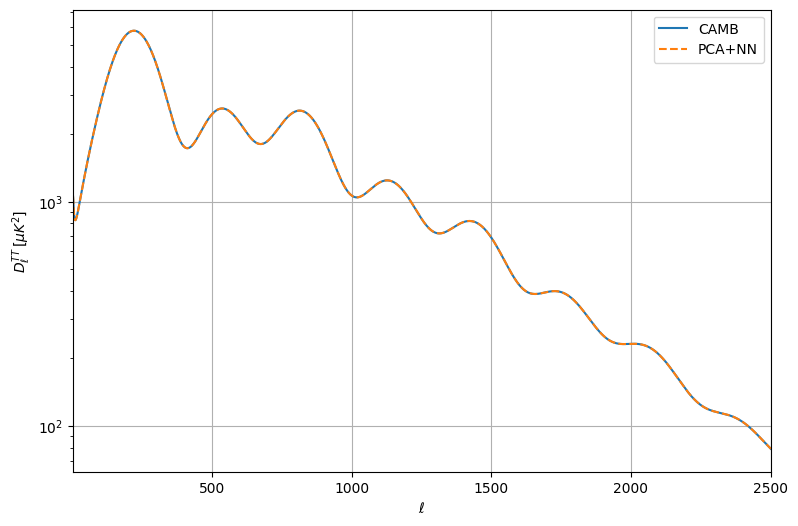

In [232]:
import matplotlib.pyplot as plt

#ell = np.arange(len(camb_tt))
factor=((2.7255e6)**2)*ell_range*(ell_range+1)/(2.*np.pi)
plt.figure(figsize=(9, 6))
camb_tt=Cltt_camb[0][2:Clee_emu.shape[1]+2]
plt.plot(ell_range, camb_tt, label='CAMB')
plt.plot(ell_range, factor*Cltt_emu[0], '--', label='PCA+NN')

plt.xlim(2, 2500)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{TT}\,[\mu K^2]$')
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

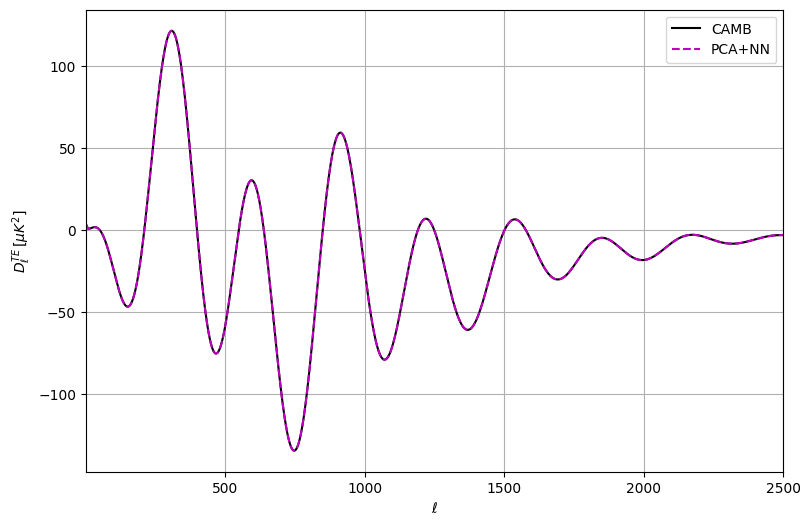

In [238]:
#ell = np.arange(len(camb_tt))
factor=((2.7255e6)**2)*ell_range*(ell_range+1)/(2.*np.pi)
plt.figure(figsize=(9, 6))
camb_te=Clte_camb[0][2:Clee_emu.shape[1]+2]
plt.plot(ell_range, camb_te,color='k', label='CAMB')
#plt.plot(ell_range, abs(camb_te), color='k',ls='--')
plt.plot(ell_range, factor*Clte_emu[0], ls='--',color='m', label='PCA+NN')
#plt.plot(ell_range, abs(factor*Clte_emu[0]), ls='--', color='m',)

plt.xlim(2, 2500)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{TE}\,[\mu K^2]$')
#plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

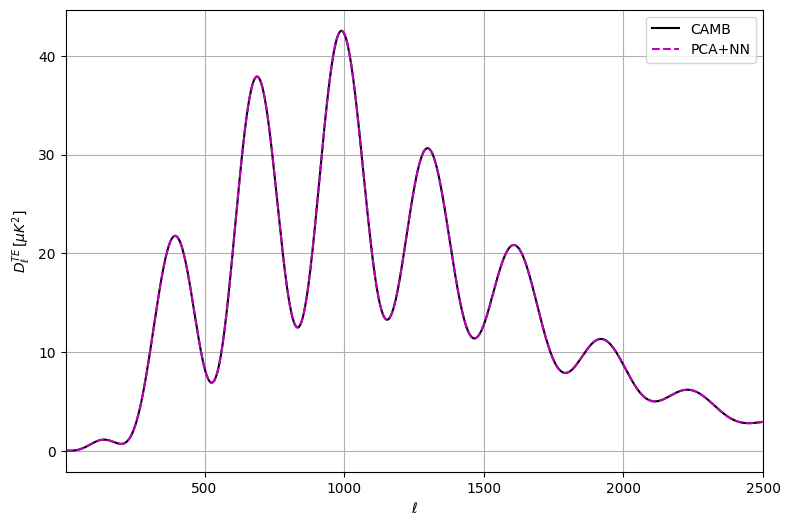

In [239]:
#ell = np.arange(len(camb_tt))
factor=((2.7255e6)**2)*ell_range*(ell_range+1)/(2.*np.pi)
plt.figure(figsize=(9, 6))
camb_ee=Clee_camb[0][2:Clee_emu.shape[1]+2]
plt.plot(ell_range, camb_ee,color='k', label='CAMB')
#plt.plot(ell_range, abs(camb_te), color='k',ls='--')
plt.plot(ell_range, factor*Clee_emu[0], ls='--',color='m', label='PCA+NN')
#plt.plot(ell_range, abs(factor*Clte_emu[0]), ls='--', color='m',)

plt.xlim(2, 2500)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{TE}\,[\mu K^2]$')
#plt.yscale("log")
plt.legend()
plt.grid()
plt.show()